<a href="https://colab.research.google.com/github/doney25/CaseStudy/blob/main/Intermediate_Assessment_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("/content/train_LZdllcl.csv")
test = pd.read_csv("/content/test_2umaH9m.csv")
sample = pd.read_csv("/content/sample_submission_M0L0uXE.csv")

In [3]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [5]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [6]:
train.shape

(54808, 14)

In [7]:
test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [8]:
test.shape

(23490, 13)

In [9]:
print(train.duplicated().sum())
print(test.duplicated().sum())

0
0


In [10]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [11]:
test.isnull().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


In [12]:
train["is_promoted"].value_counts()

,count
is_promoted,
0,50140
1,4668


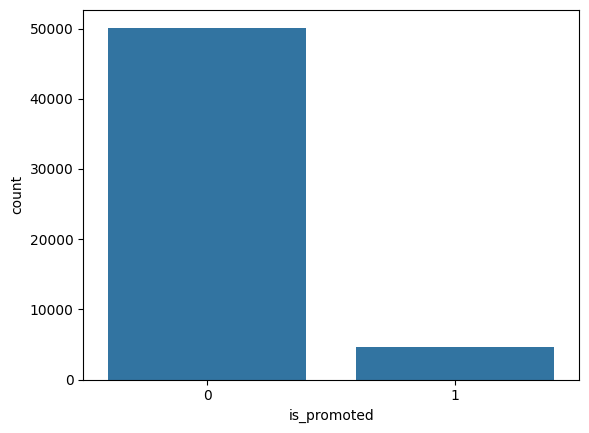

In [13]:
sns.countplot(x="is_promoted", data=train)
plt.show()

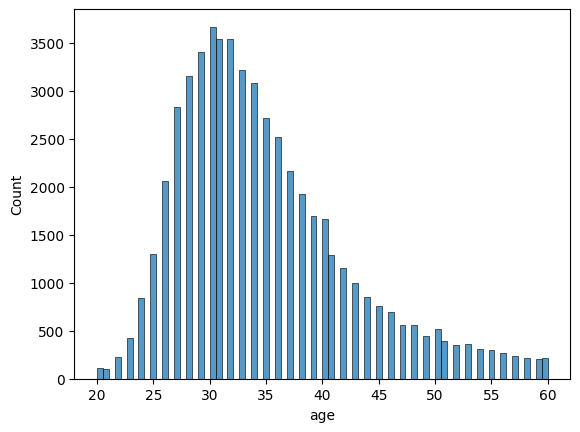

In [14]:
sns.histplot(train["age"])
plt.show()

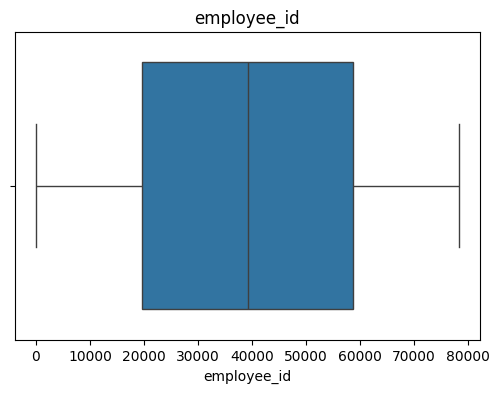

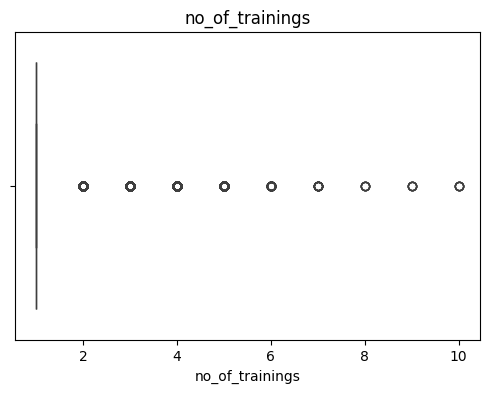

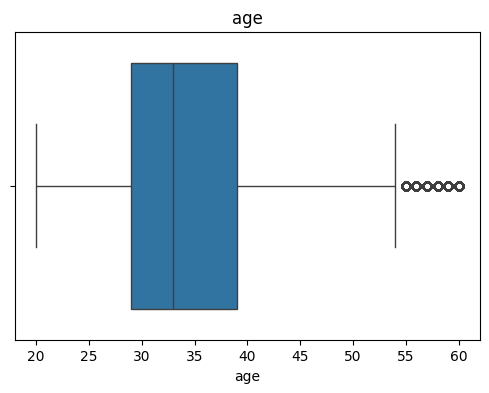

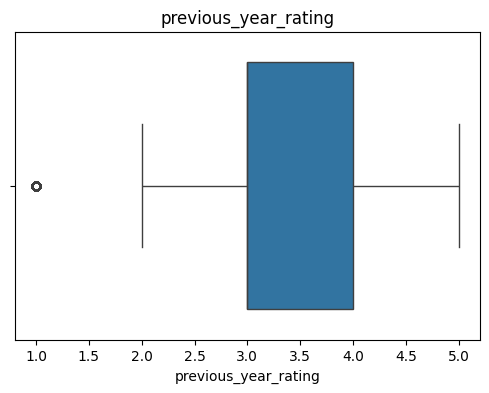

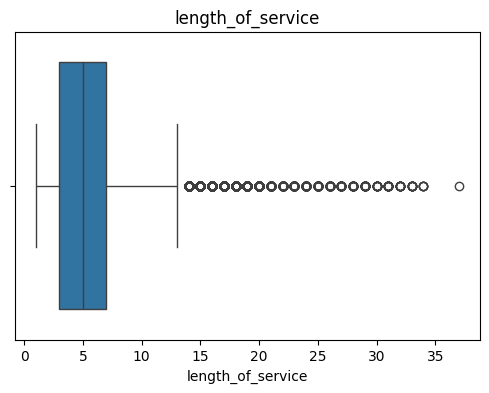

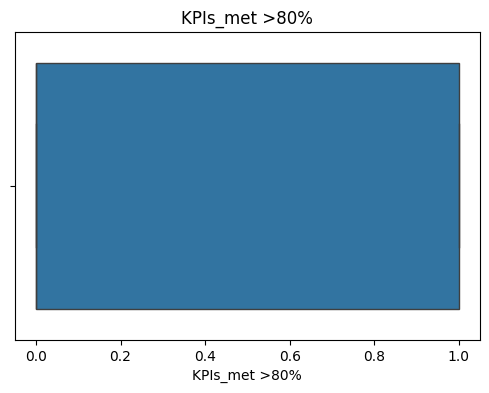

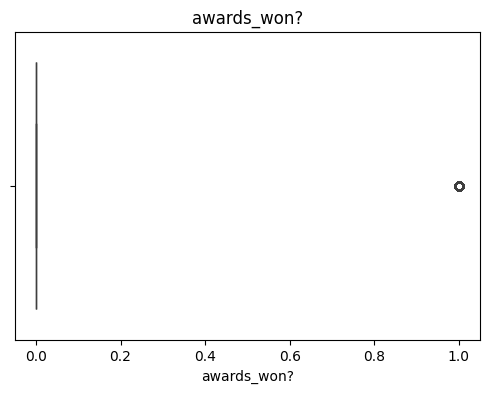

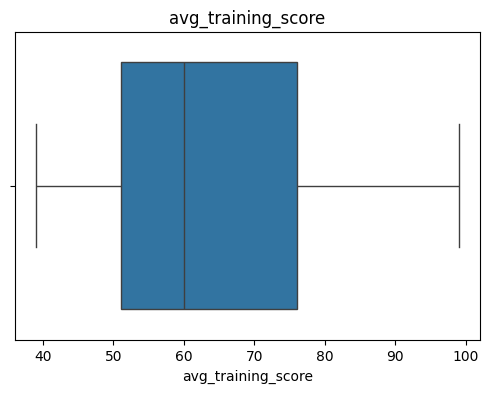

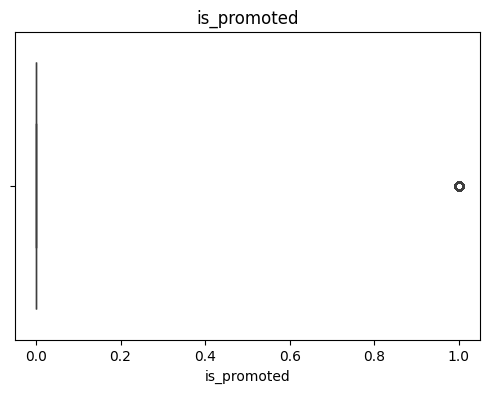

In [15]:
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

##PreProcessing

In [16]:
train.drop("employee_id", axis=1, inplace=True)
test.drop("employee_id", axis=1, inplace=True)

In [17]:
num_cols = ["previous_year_rating"]
for col in num_cols:
  train[col]=train[col].fillna(train[col].median())
  test[col]=test[col].fillna(test[col].median())

In [18]:
cat_cols = ["education"]
for col in cat_cols:
  train[col]=train[col].fillna(train[col].mode()[0])
  test[col]=test[col].fillna(train[col].mode()[0])

In [19]:
print(train.isnull().sum())
print()
print(test.isnull().sum())

department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
dtype: int64


##Encoding


In [20]:
y = train["is_promoted"]
X = train.drop("is_promoted", axis=1)

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['department', 'region', 'education', 'gender', 'recruitment_channel']:
    X[col] = le.fit_transform(X[col])
    test[col] = le.fit_transform(test[col])

##Models

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=42)

####Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_valid)
print(accuracy_score(y_valid, y_pred))

0.9347746761539865


####Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred = lr.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.919722678343368


####Regression Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8974639664294837


####XGBoost

In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.9425287356321839


##Tuning

In [29]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,subsample=0.8,olsample_bytree=0.8,random_state=42)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_valid)

print(accuracy_score(y_valid, pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:49:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "olsample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.9438058748403576


##GridSearch CV

In [30]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200],'max_depth': [3, 5, 7],'learning_rate': [0.01, 0.05, 0.1]}
xgb = XGBClassifier(random_state=42)

grid_search = GridSearchCV(estimator=xgb,param_grid=param_grid,cv=3,scoring='accuracy',n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best score: 0.9417962422109083


In [31]:
best_model = grid_search.best_estimator_
pred = best_model.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.9433497536945813


In [32]:
train_pred = best_model.predict(X_train)
valid_pred = best_model.predict(X_valid)

train_acc = accuracy_score(y_train, train_pred)
valid_acc = accuracy_score(y_valid, valid_pred)

print("Training accuracy:", train_acc)
print("Validation accuracy:", valid_acc)

Training accuracy: 0.9449664735665739
Validation accuracy: 0.9433497536945813


##Predicting

In [33]:
test_pred = best_model.predict(test)

In [34]:
submission = sample.copy()
submission["is_promoted"] = test_pred
submission

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0
...,...,...
23485,53478,0
23486,25600,0
23487,45409,0
23488,1186,0


In [35]:
submission.to_csv("submission.csv", index=False)

In [36]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>